In [1]:
import pandas as pd
import numpy as np
from cuml.ensemble import RandomForestClassifier
from cuml.svm import SVC

from xgboost import XGBClassifier

model = XGBClassifier(
    tree_method='gpu_hist',
    predictor='gpu_predictor'
)

from lightgbm import LGBMClassifier

model = LGBMClassifier(device='gpu')

import torch
print(torch.cuda.is_available())

class DataPreprocess:

    def __init__(self, file_path):
        # Read CSV file
        self.df = pd.read_csv(file_path)
        print("Dataset loaded successfully.")
        print("Shape:", self.df.shape)

    def handle_missing_values(self):
        # Fill numerical columns with median
        num_cols = self.df.select_dtypes(include=['int64', 'float64']).columns
        self.df[num_cols] = self.df[num_cols].fillna(self.df[num_cols].median())

        # Fill categorical columns with mode
        cat_cols = self.df.select_dtypes(include=['object']).columns
        self.df[cat_cols] = self.df[cat_cols].fillna(self.df[cat_cols].mode().iloc[0])

        print("Missing values handled.")

    def encode_categorical(self):

        self.df['alcohol_intake'] = (
            self.df['alcohol_consumption']
            .str.lower()
            .map({'none': 0, 'occasionally': 1, 'regularly': 2})
        )

        self.df['smoking'] = (
            self.df['smoking_level']
            .str.lower()
            .map({'non-smoker': 0, 'light': 1, 'heavy': 2})
        )

        self.df['mental_health_spt'] = (
            self.df['mental_health_support']
            .str.lower()
            .map({'yes': 0, 'no': 1})
        )

        self.df['exercise'] = (
            self.df['exercise_type']
            .str.lower()
            .map({'none': 0, 'cardio': 1, 'strength': 2, 'mixed': 3})
        )

        self.df['sunlight'] = (
            self.df['sunlight_exposure']
            .str.lower()
            .map({'low': 0, 'high': 1, 'moderate': 2})
        )

        self.df['sleep quality'] = (
            self.df['sleep_quality']
            .str.lower()
            .map({'good': 1, 'poor': 0, 'excellent': 2, 'fair': 1})
        )

        print("Categorical encoding completed.")

    def create_disease_labels(self):

        # High Insulin Flag (Assuming fasting insulin)
        self.df['High_Insulin'] = np.where(
            self.df['insulin'] > 25, 1, 0
        )
        # Diabetes
        self.df['Diabetes'] = np.where(
            ((self.df['glucose'] >= 126) & (self.df['sugar_intake'] > 50)) |
              ((self.df['bmi'] >= 30) & (self.df['sugar_intake'] > 50)) |
              ( (self.df['High_Insulin'] == 1)),
            1, 0
        )

        # Hypertension
        self.df['Hypertension'] = np.where(
            (self.df['blood_pressure'] >= 140) & (self.df['age'] >= 35)|
            ((self.df['bmi'] >= 30) & (self.df['stress_level'] > 6) &
             (self.df['age'] >= 35)),
            1, 0
        )

        # Cardiovascular
        self.df['Cardiovascular'] = np.where(
            (self.df['cholesterol'] >= 240) |
            ((self.df['smoking'] == 2) &
            (self.df['Hypertension'] == 1) &
            (self.df['Diabetes'] == 1))  |
            ((self.df['stress_level'] > 6) &
            (self.df['smoking'] == 2) &
            (self.df['Hypertension'] == 1) &
             (self.df['heart_rate'] > 90))    ,
            1, 0
        )

        # Obesity Class
        def bmi_category(bmi):
            if bmi < 26:
                return 0
            elif bmi >= 26 and bmi < 30:
                return 1
            else:
                return 2

        self.df['Obesity_Class'] = self.df['bmi'].apply(bmi_category)

        # Healthy
        self.df['Healthy'] = np.where(
            (self.df['Diabetes'] == 0) &
            (self.df['Hypertension'] == 0) &
            (self.df['Cardiovascular'] == 0) &
            (self.df['Obesity_Class'] < 2),
            1, 0
        )

        print("Disease labels created.")

    def get_processed_data(self):
        return self.df


# Execute the code and create a new Master file with proper data
processor = DataPreprocess("Master dataset.csv")


processor.encode_categorical()
processor.create_disease_labels()
processor.handle_missing_values()

df_processed = processor.get_processed_data()

df_processed.head()

df_processed = df_processed.drop(columns=["occupation", "insurance", "device_usage",
                      "bmi_estimated", "bmi_scaled", "bmi_corrected", "work_hours",
                      "education_level", "target", "electrolyte_level", "gene_marker_flag",
                      "environmental_risk_score", "daily_supplement_dosage"
                      ])

df_processed.to_csv("Master_dataset_with_labels.csv", index=False)
print("New dataset saved successfully.")



True
Dataset loaded successfully.
Shape: (100000, 48)
Categorical encoding completed.
Disease labels created.
Missing values handled.
New dataset saved successfully.


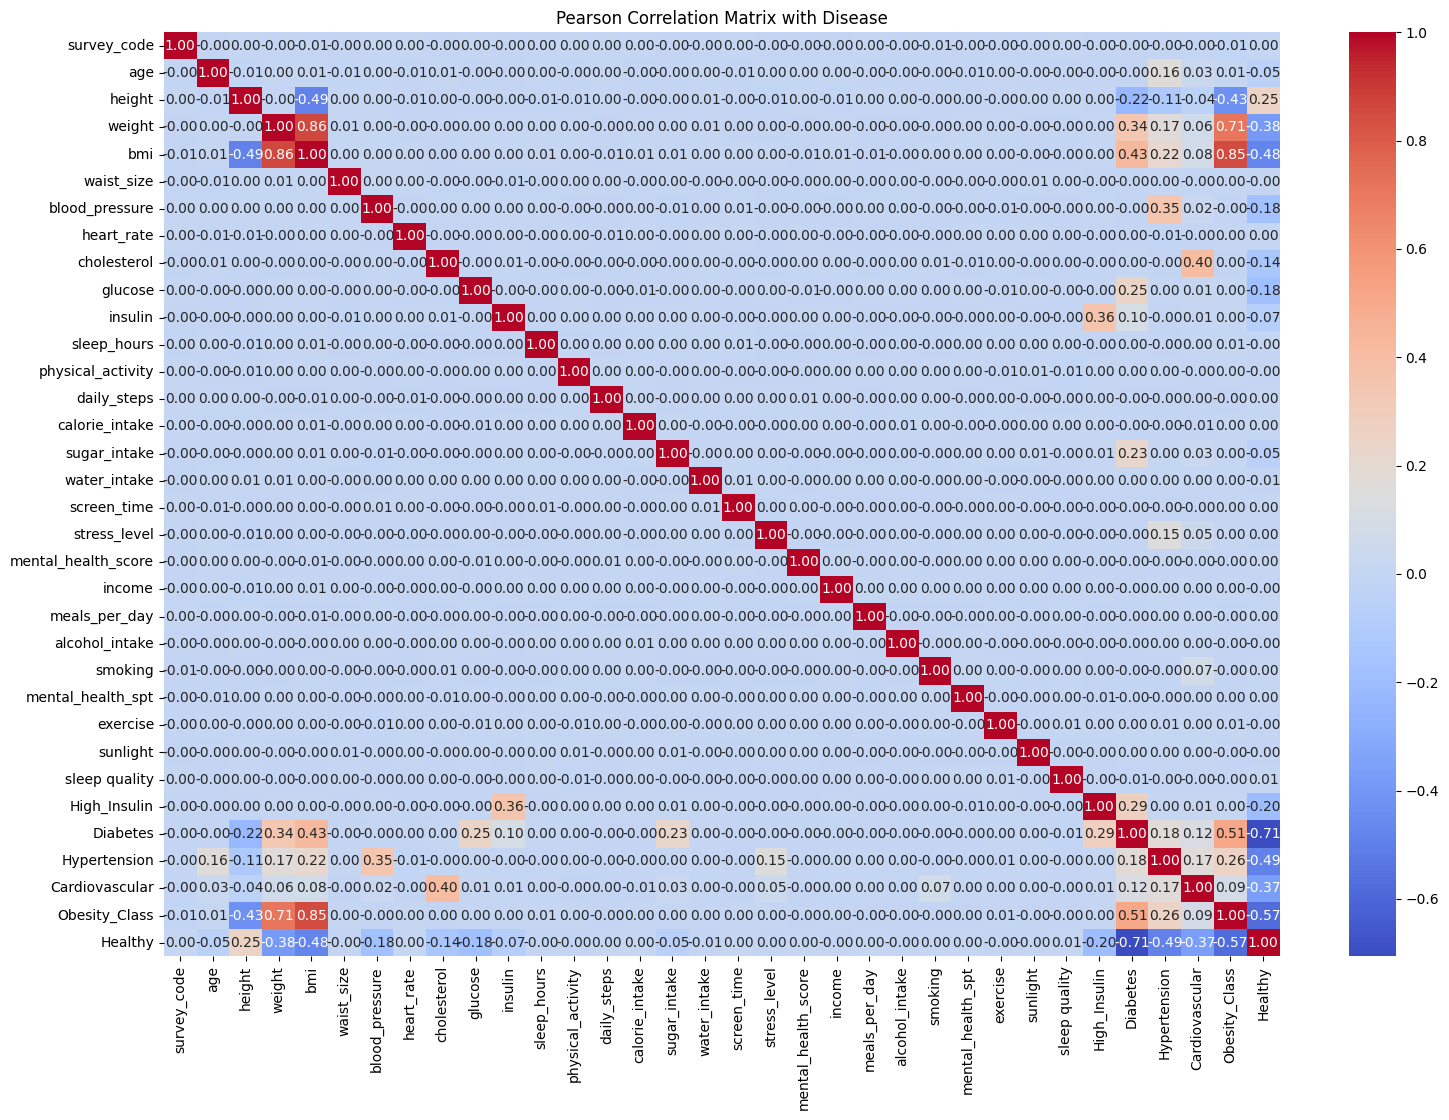

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Master_dataset_with_labels.csv")

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

# Compute Pearson correlation
corr_matrix = numeric_df.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Pearson Correlation Matrix with Disease")
plt.show()

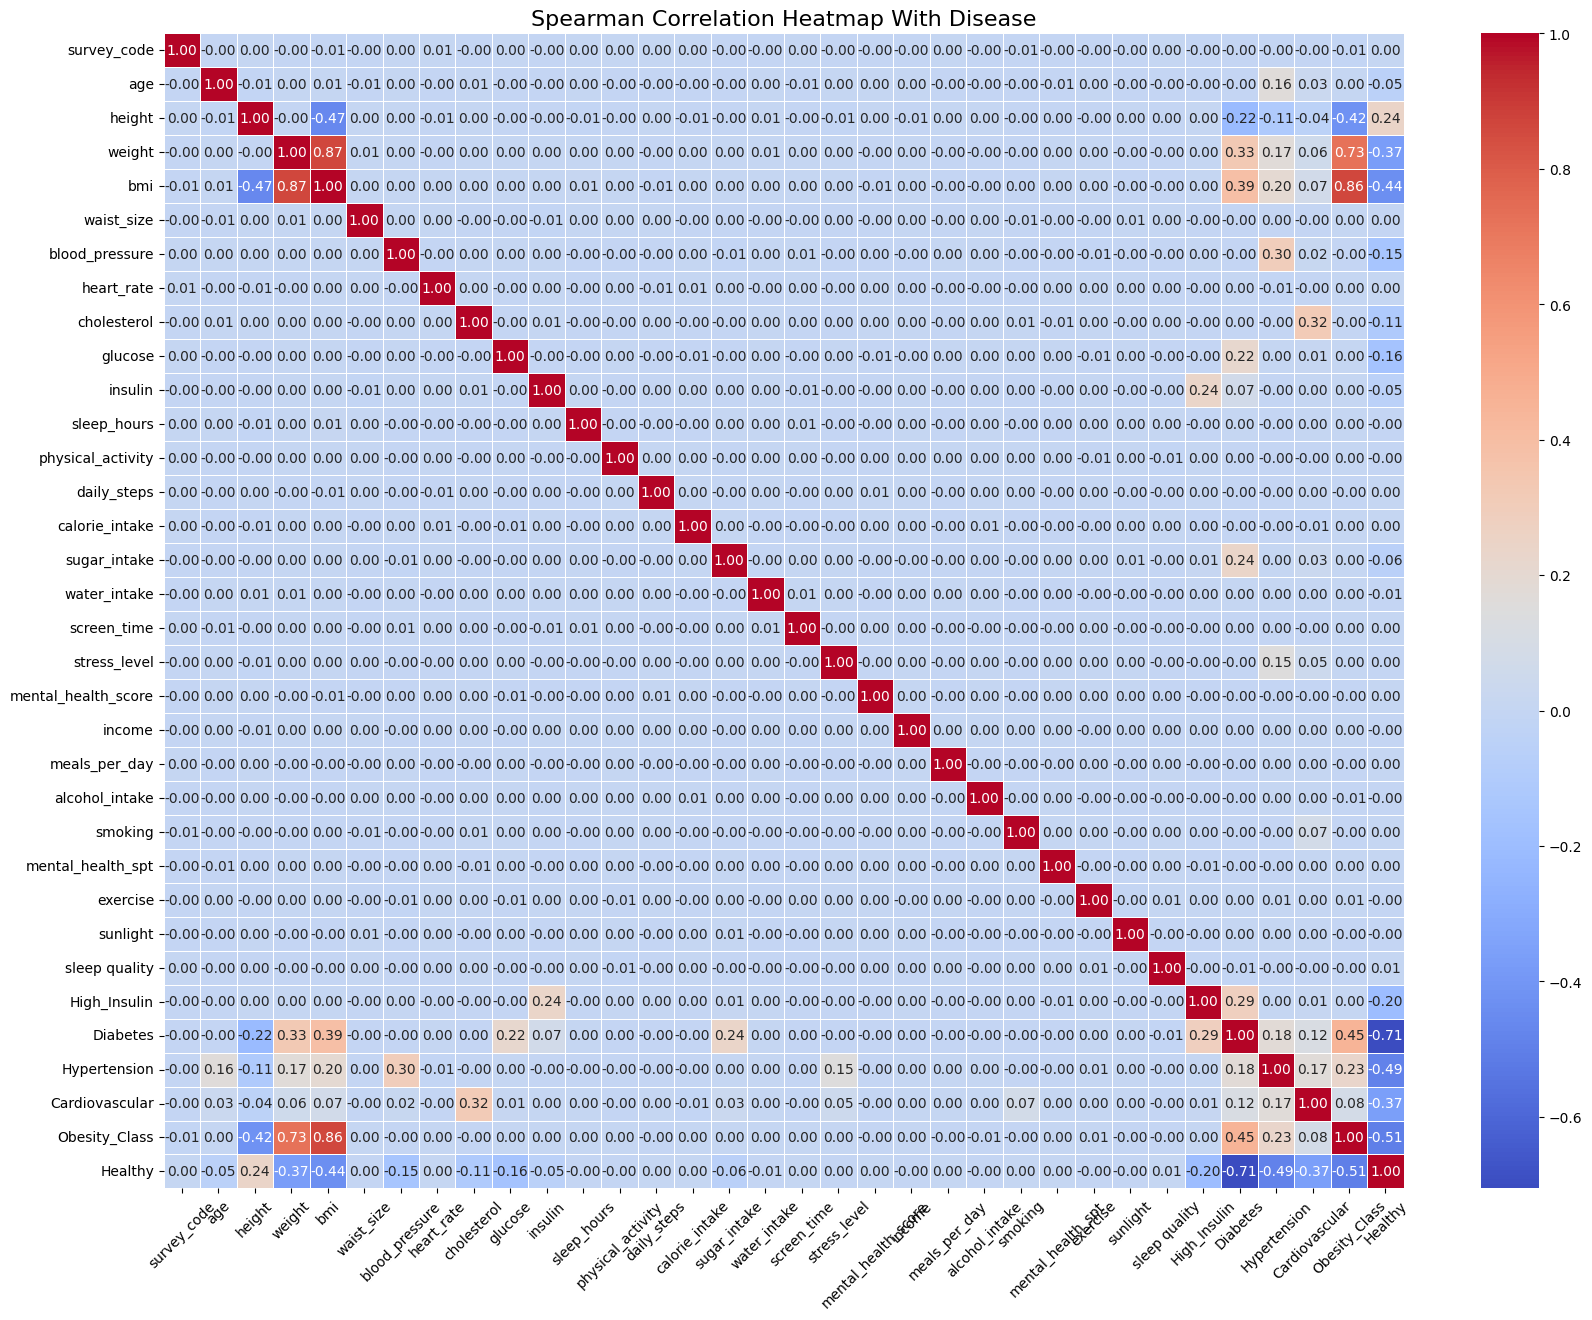

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Master_dataset_with_labels.csv")

# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate Spearman correlation
spearman_corr = numeric_df.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(20,15))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap With Disease", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, accuracy_score

from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

In [3]:
X = df_processed.drop([
    'bmi',
    'glucose',
    'Diabetes',
    'Hypertension',
    'Cardiovascular',
    'Obesity_Class',
    'High_Insulin',
    'insulin',
    'Healthy'
], axis=1)

y = df_processed[['Diabetes', 'Hypertension', 'Cardiovascular' , 'Obesity_Class']]

X = pd.get_dummies(X, drop_first=True)

X_columns = X.columns

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train_res, y_train_res = smote.fit_resample(X_train, y_train['Cardiovascular'])

In [6]:
models = {

    "Logistic Regression":
    MultiOutputClassifier(LogisticRegression(max_iter=1500, class_weight={0:1, 1:4, 2:4})),

    "KNN":
    MultiOutputClassifier(KNeighborsClassifier(n_neighbors=15, weights='distance')),

    "SVM":
    MultiOutputClassifier(SVC(probability=True)),

    "Decision Tree":
    MultiOutputClassifier(DecisionTreeClassifier(class_weight={0:1, 1:4, 2:4})),

    "Random Forest":
    MultiOutputClassifier(RandomForestClassifier(n_estimators=500, class_weight={0:1, 1:4, 2:4})),

    "XGBoost":
    MultiOutputClassifier(XGBClassifier(tree_method='hist', eval_metric='logloss'))
}
import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save column names
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [7]:
results = []

for name, model in models.items():

    print("\n==========================")
    print("Model:", name)

    model.fit(X_train, y_train)

    # ── Save each trained model immediately after fitting ──
    import joblib
    safe_name = name.replace(" ", "")
    joblib.dump(model, f"best_model_{safe_name}.pkl")
    print(f"Saved: best_model_{safe_name}.pkl")



    # Default predictions
    y_pred = model.predict(X_test)

    #  Handle probability safely
    try:
        y_prob = model.predict_proba(X_test)

        # Modify ONLY Cardiovascular (index = 2)
        y_pred[:, 2] = (y_prob[2][:, 1] > 0.6).astype(int)

    except:
        print(" predict_proba not available for", name)

    # Accuracy per target
    acc_diabetes = accuracy_score(y_test['Diabetes'], y_pred[:,0])
    acc_hyper = accuracy_score(y_test['Hypertension'], y_pred[:,1])
    acc_cardio = accuracy_score(y_test['Cardiovascular'], y_pred[:,2])
    acc_obesity = accuracy_score(y_test['Obesity_Class'], y_pred[:,3])

    acc = (acc_diabetes + acc_hyper + acc_cardio + acc_obesity) / 4

    results.append([name, acc])

    # Print results
    print("Diabetes Accuracy:", acc_diabetes)
    print("Hypertension Accuracy:", acc_hyper)
    print("Cardiovascular Accuracy:", acc_cardio)
    print("Obesity Accuracy:", acc_obesity)

    print("\nDiabetes Report")
    print(classification_report(y_test['Diabetes'], y_pred[:,0], zero_division=0))

    print("\nHypertension Report")
    print(classification_report(y_test['Hypertension'], y_pred[:,1], zero_division=0))

    print("\nCardiovascular Report")
    print(classification_report(y_test['Cardiovascular'], y_pred[:,2], zero_division=0))

    print("\nObesity Report")
    print(classification_report(y_test['Obesity_Class'], y_pred[:,3], zero_division=0))


Model: Logistic Regression
Saved: best_model_LogisticRegression.pkl
Diabetes Accuracy: 0.7579
Hypertension Accuracy: 0.88015
Cardiovascular Accuracy: 0.9519
Obesity Accuracy: 0.988

Diabetes Report
              precision    recall  f1-score   support

           0       0.93      0.76      0.84     16165
           1       0.43      0.76      0.55      3835

    accuracy                           0.76     20000
   macro avg       0.68      0.76      0.69     20000
weighted avg       0.83      0.76      0.78     20000


Hypertension Report
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     17918
           1       0.45      0.71      0.55      2082

    accuracy                           0.88     20000
   macro avg       0.71      0.81      0.74     20000
weighted avg       0.91      0.88      0.89     20000


Cardiovascular Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     

In [8]:
results_df = pd.DataFrame(results, columns=["Model", "Average Accuracy"])
results_df = results_df.sort_values(by="Average Accuracy", ascending=False)

print(results_df)


                 Model  Average Accuracy
5              XGBoost          0.978650
4        Random Forest          0.971700
3        Decision Tree          0.962237
2                  SVM          0.947900
0  Logistic Regression          0.894487
1                  KNN          0.831650


In [9]:
import joblib

scaler = joblib.load("scaler.pkl")
model_columns = joblib.load("model_columns.pkl")

# Safe check
if hasattr(scaler, "feature_names_in_"):
    print("Scaler expects:", scaler.feature_names_in_.tolist())
else:
    print("Scaler does not store feature names ")

print("\nModel columns:", model_columns)

print("\nDone")

Scaler expects: ['survey_code', 'age', 'height', 'weight', 'waist_size', 'blood_pressure', 'heart_rate', 'cholesterol', 'sleep_hours', 'physical_activity', 'daily_steps', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level', 'mental_health_score', 'income', 'meals_per_day', 'alcohol_intake', 'smoking', 'mental_health_spt', 'exercise', 'sunlight', 'sleep quality', 'gender_Male', 'sleep_quality_Fair', 'sleep_quality_Good', 'sleep_quality_Poor', 'alcohol_consumption_Regularly', 'smoking_level_Light', 'smoking_level_Non-smoker', 'mental_health_support_Yes', 'job_type_Labor', 'job_type_Office', 'job_type_Service', 'job_type_Tech', 'job_type_Unemployed', 'diet_type_Omnivore', 'diet_type_Vegan', 'diet_type_Vegetarian', 'exercise_type_Mixed', 'exercise_type_Strength', 'healthcare_access_Moderate', 'healthcare_access_Poor', 'sunlight_exposure_Low', 'sunlight_exposure_Moderate', 'caffeine_intake_Moderate', 'family_history_Yes', 'pet_owner_Yes']

Model columns: ['survey

In [11]:


import numpy as np
import pandas as pd
import joblib

EXCEL_PATH  = "Extrinsic test.xlsx"
SCALER_PATH = "scaler.pkl"

MODEL_FILES = {
    "Decision Tree": "best_model_DecisionTree.pkl",
    "Random Forest": "best_model_RandomForest.pkl",
    "XGBoost": "best_model_XGBoost.pkl",
    "Logistic Regression": "best_model_LogisticRegression.pkl",
    "KNN": "best_model_KNN.pkl",
    "SVM": "best_model_SVM.pkl"
}

TARGET_COLS = ['Diabetes', 'Hypertension', 'Cardiovascular', 'Obesity_Class']

LABEL_MAP = {
    'Diabetes':       {0: 'No Diabetes',     1: 'Diabetic'},
    'Hypertension':   {0: 'No Hypertension', 1: 'Hypertensive'},
    'Cardiovascular': {0: 'No CVD Risk',     1: 'CVD Risk'},
    'Obesity_Class':  {0: 'Normal Weight',   1: 'Overweight', 2: 'Obese'},
}



scaler         = joblib.load(SCALER_PATH)
scaler_columns = scaler.feature_names_in_.tolist()
print(f" Scaler loaded — expects {len(scaler_columns)} features.")



df_raw = pd.read_excel(EXCEL_PATH)
print(f" Dataset loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

df = df_raw.copy()


df['alcohol_intake'] = df['alcohol_consumption'].str.lower().map(
    {'none': 0, 'occasionally': 1, 'regularly': 2})

df['smoking'] = df['smoking_level'].str.lower().map(
    {'non-smoker': 0, 'light': 1, 'heavy': 2})

df['mental_health_spt'] = df['mental_health_support'].str.lower().map(
    {'yes': 0, 'no': 1})

df['exercise'] = df['exercise_type'].str.lower().map(
    {'none': 0, 'cardio': 1, 'strength': 2, 'mixed': 3})

df['sunlight'] = df['sunlight_exposure'].str.lower().map(
    {'low': 0, 'high': 1, 'moderate': 2})

df['sleep quality'] = df['sleep_quality'].str.lower().map(
    {'good': 1, 'poor': 0, 'excellent': 2, 'fair': 1})


drop_cols = [
    'survey_code',
    'bmi', 'glucose', 'insulin',                          # used to create labels
    'Diabetes', 'Hypertension', 'Cardiovascular',          # labels
    'Obesity_Class', 'High_Insulin', 'Healthy',            # labels

    'alcohol_consumption', 'smoking_level', 'mental_health_support',
    'exercise_type', 'sunlight_exposure', 'sleep_quality',
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')


df = pd.get_dummies(df, drop_first=True)


missing = [c for c in scaler_columns if c not in df.columns]
extra   = [c for c in df.columns if c not in scaler_columns]

for col in missing:
    df[col] = 0


if extra:
    print(f"  Dropping {len(extra)} extra columns not seen during training: {extra}")

df = df[scaler_columns]   # enforce exact order


df_scaled = scaler.transform(df)
print(f"\n Features aligned and scaled: {df_scaled.shape[1]} columns.\n")



all_results = {}

for model_name, model_file in MODEL_FILES.items():
    model  = joblib.load(model_file)
    y_pred = model.predict(df_scaled)
    y_prob = model.predict_proba(df_scaled)


    cardio_probs = y_prob[2][:, 1]
    y_pred[:, 2] = (cardio_probs > 0.6).astype(int)

    rows = []
    for i in range(len(df_raw)):
        row = {"Survey Code": int(df_raw['survey_code'].iloc[i])}
        for j, disease in enumerate(TARGET_COLS):
            pred = int(y_pred[i, j])
            prob = round(cardio_probs[i] if disease == 'Cardiovascular'
                         else y_prob[j][i][1], 3)
            row[disease]           = LABEL_MAP[disease].get(pred, str(pred))
            row[f"{disease}_prob"] = prob
        rows.append(row)

    all_results[model_name] = pd.DataFrame(rows)

# ─────────────────────────────────────────────
# Display per-model results
# ─────────────────────────────────────────────

for model_name, result_df in all_results.items():
    print("=" * 70)
    print(f"  MODEL: {model_name}")
    print("=" * 70)
    for _, row in result_df.iterrows():
        print(f"\n  Survey Code: {int(row['Survey Code'])}")
        for disease in TARGET_COLS:
            label = row[disease]
            prob  = row[f"{disease}_prob"]
            bar   = "|" * int(prob * 20)
            print(f"    {disease:<16}: {label:<20} (prob: {prob:.2f})  {bar}")
    print()

# ─────────────────────────────────────────────
# Summary table — models side by side
# ─────────────────────────────────────────────

print("\n" + "=" * 70)
print("  SUMMARY — All models side by side")
print("=" * 70)

for disease in TARGET_COLS:
    print(f"\n  {disease}")
    header = f"  {'Survey':<10}"
    for m in MODEL_FILES:
        header += f"  {m:<22}"
    print(header)
    print("  " + "-" * (10 + 24 * len(MODEL_FILES)))

    for _, row in df_raw.iterrows():
        sc   = int(row['survey_code'])
        line = f"  {sc:<10}"
        for model_name in MODEL_FILES:
            label = all_results[model_name].loc[
                all_results[model_name]['Survey Code'] == sc, disease
            ].values[0]
            line += f"  {label:<22}"
        print(line)

print("\n Done.")

# ─────────────────────────────────────────────
# ENSEMBLE PREDICTION FOR ALL DISEASE
# ─────────────────────────────────────────────

print("\n" + "=" * 70)
print("  FINAL ENSEMBLE PREDICTIONS")
print("=" * 70)

def risk_from_votes(votes, total):
    if votes >= 3:
        return "HIGH RISK"
    elif votes >= 2:
        return "MODERATE RISK"
    else:
        return "LOW RISK"

ensemble_rows = []

for i, row in df_raw.iterrows():

    sc = int(row['survey_code'])
    final_row = {"Survey Code": sc}

    print(f"\n Survey Code: {sc}")

    for disease in TARGET_COLS:

        votes = 0
        probs = []

        # Collect predictions from all models
        for model_name in MODEL_FILES:
            model_df = all_results[model_name]

            pred_label = model_df.loc[
                model_df['Survey Code'] == sc, disease
            ].values[0]

            prob = model_df.loc[
                model_df['Survey Code'] == sc, f"{disease}_prob"
            ].values[0]

            probs.append(prob)

            # Count votes
            if disease == "Obesity_Class":
                if pred_label in ["Overweight", "Obese"]:
                    votes += 1
            else:
                if "No" not in pred_label:
                    votes += 1

        total_models = len(MODEL_FILES)

        # -----------------------------
        # NEW IMPROVED SCORING
        # -----------------------------
        vote_score = (votes / total_models) * 100
        avg_prob = np.mean(probs)
        prob_score = avg_prob * 100

        # Weighted final score (more weight to voting)
        final_score = int((vote_score * 0.7) + (prob_score * 0.3))

        # Risk from voting (more stable)
        risk = risk_from_votes(votes, total_models)

        confidence = f"{votes}/{total_models} models"

        # Label (optional interpretation)
        if disease == "Obesity_Class":
            if final_score >= 70:
                label = "Obese"
            elif final_score >= 40:
                label = "Overweight"
            else:
                label = "Normal Weight"
        else:
            label = "Positive" if votes >= 2 else "Negative"

        # Visual bar
        bar = "|" * int(final_score / 5)

        print(f"  {disease:<16}: {risk:<15} "
              f"(Score: {final_score:3d}, Votes: {confidence}) {bar}")

        # Save
        final_row[disease] = risk
        final_row[f"{disease}_score"] = final_score
        final_row[f"{disease}_votes"] = votes
        final_row[f"{disease}_confidence"] = confidence

    ensemble_rows.append(final_row)

# Convert to DataFrame
ensemble_df = pd.DataFrame(ensemble_rows)

# ─────────────────────────────────────────────
# FINAL TABLE OUTPUT
# ─────────────────────────────────────────────

final_clean = ensemble_df[
    ["Survey Code", "Diabetes", "Hypertension", "Cardiovascular", "Obesity_Class"]
].copy()


for col in ["Diabetes", "Hypertension", "Cardiovascular", "Obesity_Class"]:
    final_clean[col] = final_clean[col].str.lower()

print("\n" + "=" * 70)
print("  FINAL PREDICTION TABLE")
print("=" * 70)

print(final_clean)

# Save to Excel
final_clean.to_excel("final_clean_output.xlsx", index=False)



 Scaler loaded — expects 50 features.
 Dataset loaded: 10 rows, 38 columns.

 Features aligned and scaled: 50 columns.

  MODEL: Decision Tree

  Survey Code: 1
    Diabetes        : No Diabetes          (prob: 0.00)  
    Hypertension    : No Hypertension      (prob: 0.00)  
    Cardiovascular  : No CVD Risk          (prob: 0.00)  
    Obesity_Class   : Normal Weight        (prob: 0.00)  

  Survey Code: 2
    Diabetes        : Diabetic             (prob: 1.00)  ||||||||||||||||||||
    Hypertension    : No Hypertension      (prob: 0.00)  
    Cardiovascular  : No CVD Risk          (prob: 0.00)  
    Obesity_Class   : Obese                (prob: 0.00)  

  Survey Code: 3
    Diabetes        : No Diabetes          (prob: 0.00)  
    Hypertension    : No Hypertension      (prob: 0.00)  
    Cardiovascular  : No CVD Risk          (prob: 0.00)  
    Obesity_Class   : Normal Weight        (prob: 0.00)  

  Survey Code: 4
    Diabetes        : Diabetic             (prob: 1.00)  ||||||||||||

In [13]:


import numpy as np
import pandas as pd
import joblib

# ─────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────

EXCEL_PATH  = "Test Set Testing.xlsx"
SCALER_PATH = "scaler.pkl"

MODEL_FILES = {
    "Decision Tree": "best_model_DecisionTree.pkl",
    "Random Forest": "best_model_RandomForest.pkl",
    "XGBoost": "best_model_XGBoost.pkl",
    "Logistic Regression": "best_model_LogisticRegression.pkl",
    "KNN": "best_model_KNN.pkl",
    "SVM": "best_model_SVM.pkl"
}

TARGET_COLS = ['Diabetes', 'Hypertension', 'Cardiovascular', 'Obesity_Class']

LABEL_MAP = {
    'Diabetes':       {0: 'No Diabetes',     1: 'Diabetic'},
    'Hypertension':   {0: 'No Hypertension', 1: 'Hypertensive'},
    'Cardiovascular': {0: 'No CVD Risk',     1: 'CVD Risk'},
    'Obesity_Class':  {0: 'Normal Weight',   1: 'Overweight', 2: 'Obese'},
}

# ─────────────────────────────────────────────
# Load scaler — its feature list is ground truth
# ─────────────────────────────────────────────

scaler         = joblib.load(SCALER_PATH)
scaler_columns = scaler.feature_names_in_.tolist()
print(f" Scaler loaded — expects {len(scaler_columns)} features.")

# ─────────────────────────────────────────────
# Load & preprocess extrinsic dataset
# ─────────────────────────────────────────────

df_raw = pd.read_excel(EXCEL_PATH)
print(f" Dataset loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

df = df_raw.copy()

# Step 1: Apply same manual encoding as DataPreprocess.encode_categorical()
df['alcohol_intake'] = df['alcohol_consumption'].str.lower().map(
    {'none': 0, 'occasionally': 1, 'regularly': 2})

df['smoking'] = df['smoking_level'].str.lower().map(
    {'non-smoker': 0, 'light': 1, 'heavy': 2})

df['mental_health_spt'] = df['mental_health_support'].str.lower().map(
    {'yes': 0, 'no': 1})

df['exercise'] = df['exercise_type'].str.lower().map(
    {'none': 0, 'cardio': 1, 'strength': 2, 'mixed': 3})

df['sunlight'] = df['sunlight_exposure'].str.lower().map(
    {'low': 0, 'high': 1, 'moderate': 2})

df['sleep quality'] = df['sleep_quality'].str.lower().map(
    {'good': 1, 'poor': 0, 'excellent': 2, 'fair': 1})

# Step 2: Drop label/identifier/source columns
drop_cols = [
    'survey_code',
    'bmi', 'glucose', 'insulin',                          # used to create labels
    'Diabetes', 'Hypertension', 'Cardiovascular',          # labels
    'Obesity_Class', 'High_Insulin', 'Healthy',            # labels
    # raw categorical columns — already encoded above
    'alcohol_consumption', 'smoking_level', 'mental_health_support',
    'exercise_type', 'sunlight_exposure', 'sleep_quality',
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# Step 3: One-hot encode remaining categoricals
#         drop_first=True mirrors pd.get_dummies(X, drop_first=True) in mtp2.py
df = pd.get_dummies(df, drop_first=True)

# Step 4: Align to scaler's exact feature list
missing = [c for c in scaler_columns if c not in df.columns]
extra   = [c for c in df.columns if c not in scaler_columns]

for col in missing:
    df[col] = 0


if extra:
    print(f"  Dropping {len(extra)} extra columns not seen during training: {extra}")

df = df[scaler_columns]   # enforce exact order

# Step 5: Scale
df_scaled = scaler.transform(df)
print(f"\n Features aligned and scaled: {df_scaled.shape[1]} columns.\n")

# ─────────────────────────────────────────────
# Run models & collect predictions
# ─────────────────────────────────────────────

all_results = {}

for model_name, model_file in MODEL_FILES.items():
    model  = joblib.load(model_file)
    y_pred = model.predict(df_scaled)
    y_prob = model.predict_proba(df_scaled)

    # Apply same 0.6 Cardiovascular threshold from mtp2.py
    cardio_probs = y_prob[2][:, 1]
    y_pred[:, 2] = (cardio_probs > 0.6).astype(int)

    rows = []
    for i in range(len(df_raw)):
        row = {"Survey Code": int(df_raw['survey_code'].iloc[i])}
        for j, disease in enumerate(TARGET_COLS):
            pred = int(y_pred[i, j])
            prob = round(cardio_probs[i] if disease == 'Cardiovascular'
                         else y_prob[j][i][1], 3)
            row[disease]           = LABEL_MAP[disease].get(pred, str(pred))
            row[f"{disease}_prob"] = prob
        rows.append(row)

    all_results[model_name] = pd.DataFrame(rows)

# ─────────────────────────────────────────────
# Display per-model results
# ─────────────────────────────────────────────

for model_name, result_df in all_results.items():
    print("=" * 70)
    print(f"  MODEL: {model_name}")
    print("=" * 70)
    for _, row in result_df.iterrows():
        print(f"\n  Survey Code: {int(row['Survey Code'])}")
        for disease in TARGET_COLS:
            label = row[disease]
            prob  = row[f"{disease}_prob"]
            bar   = "|" * int(prob * 20)
            print(f"    {disease:<16}: {label:<20} (prob: {prob:.2f})  {bar}")
    print()

# ─────────────────────────────────────────────
# Summary table — models side by side
# ─────────────────────────────────────────────

print("\n" + "=" * 70)
print("  SUMMARY — All models side by side")
print("=" * 70)

for disease in TARGET_COLS:
    print(f"\n  {disease}")
    header = f"  {'Survey':<10}"
    for m in MODEL_FILES:
        header += f"  {m:<22}"
    print(header)
    print("  " + "-" * (10 + 24 * len(MODEL_FILES)))

    for _, row in df_raw.iterrows():
        sc   = int(row['survey_code'])
        line = f"  {sc:<10}"
        for model_name in MODEL_FILES:
            label = all_results[model_name].loc[
                all_results[model_name]['Survey Code'] == sc, disease
            ].values[0]
            line += f"  {label:<22}"
        print(line)

print("\n Done.")

# ─────────────────────────────────────────────
# ENSEMBLE PREDICTION FOR ALL DISEASE
# ─────────────────────────────────────────────

print("\n" + "=" * 70)
print("  FINAL ENSEMBLE PREDICTIONS")
print("=" * 70)

def risk_from_votes(votes, total):
    if votes >= 3:
        return "HIGH RISK"
    elif votes >= 2:
        return "MODERATE RISK"
    else:
        return "LOW RISK"

ensemble_rows = []

for i, row in df_raw.iterrows():

    sc = int(row['survey_code'])
    final_row = {"Survey Code": sc}

    print(f"\n Survey Code: {sc}")

    for disease in TARGET_COLS:

        votes = 0
        probs = []

        # Collect predictions from all models
        for model_name in MODEL_FILES:
            model_df = all_results[model_name]

            pred_label = model_df.loc[
                model_df['Survey Code'] == sc, disease
            ].values[0]

            prob = model_df.loc[
                model_df['Survey Code'] == sc, f"{disease}_prob"
            ].values[0]

            probs.append(prob)

            # Count votes
            if disease == "Obesity_Class":
                if pred_label in ["Overweight", "Obese"]:
                    votes += 1
            else:
                if "No" not in pred_label:
                    votes += 1

        total_models = len(MODEL_FILES)

        # -----------------------------
        # NEW IMPROVED SCORING
        # -----------------------------
        vote_score = (votes / total_models) * 100
        avg_prob = np.mean(probs)
        prob_score = avg_prob * 100

        # Weighted final score (more weight to voting)
        final_score = int((vote_score * 0.7) + (prob_score * 0.3))

        # Risk from voting (more stable)
        risk = risk_from_votes(votes, total_models)

        confidence = f"{votes}/{total_models} models"

        # Label (optional interpretation)
        if disease == "Obesity_Class":
            if final_score >= 70:
                label = "Obese"
            elif final_score >= 40:
                label = "Overweight"
            else:
                label = "Normal Weight"
        else:
            label = "Positive" if votes >= 2 else "Negative"

        # Visual bar
        bar = "|" * int(final_score / 5)

        print(f"  {disease:<16}: {risk:<15} "
              f"(Score: {final_score:3d}, Votes: {confidence}) {bar}")

        # Save
        final_row[disease] = risk
        final_row[f"{disease}_score"] = final_score
        final_row[f"{disease}_votes"] = votes
        final_row[f"{disease}_confidence"] = confidence

    ensemble_rows.append(final_row)

# Convert to DataFrame
ensemble_df = pd.DataFrame(ensemble_rows)

# ─────────────────────────────────────────────
# FINAL TABLE OUTPUT
# ─────────────────────────────────────────────

final_clean = ensemble_df[
    ["Survey Code", "Diabetes", "Hypertension", "Cardiovascular", "Obesity_Class"]
].copy()


for col in ["Diabetes", "Hypertension", "Cardiovascular", "Obesity_Class"]:
    final_clean[col] = final_clean[col].str.lower()

print("\n" + "=" * 70)
print("  FINAL PREDICTION TABLE")
print("=" * 70)

print(final_clean)

# Save to Excel
final_clean.to_excel("final_testdata_output.xlsx", index=False)

 Scaler loaded — expects 50 features.
 Dataset loaded: 10 rows, 41 columns.

 Features aligned and scaled: 50 columns.

  MODEL: Decision Tree

  Survey Code: 99991
    Diabetes        : No Diabetes          (prob: 0.00)  
    Hypertension    : No Hypertension      (prob: 0.00)  
    Cardiovascular  : No CVD Risk          (prob: 0.00)  
    Obesity_Class   : Normal Weight        (prob: 0.00)  

  Survey Code: 99992
    Diabetes        : No Diabetes          (prob: 0.00)  
    Hypertension    : No Hypertension      (prob: 0.00)  
    Cardiovascular  : No CVD Risk          (prob: 0.00)  
    Obesity_Class   : Normal Weight        (prob: 0.00)  

  Survey Code: 99993
    Diabetes        : No Diabetes          (prob: 0.00)  
    Hypertension    : No Hypertension      (prob: 0.00)  
    Cardiovascular  : No CVD Risk          (prob: 0.00)  
    Obesity_Class   : Overweight           (prob: 1.00)  ||||||||||||||||||||

  Survey Code: 99994
    Diabetes        : No Diabetes          (prob: 0.0

In [15]:


import numpy as np
import pandas as pd
import joblib

# ─────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────

EXCEL_PATH  = "Real life data.xlsx"
SCALER_PATH = "scaler.pkl"

MODEL_FILES = {
    "Decision Tree": "best_model_DecisionTree.pkl",
    "Random Forest": "best_model_RandomForest.pkl",
    "XGBoost": "best_model_XGBoost.pkl",
    "Logistic Regression": "best_model_LogisticRegression.pkl",
    "KNN": "best_model_KNN.pkl",
    "SVM": "best_model_SVM.pkl"
}

TARGET_COLS = ['Diabetes', 'Hypertension', 'Cardiovascular', 'Obesity_Class']

LABEL_MAP = {
    'Diabetes':       {0: 'No Diabetes',     1: 'Diabetic'},
    'Hypertension':   {0: 'No Hypertension', 1: 'Hypertensive'},
    'Cardiovascular': {0: 'No CVD Risk',     1: 'CVD Risk'},
    'Obesity_Class':  {0: 'Normal Weight',   1: 'Overweight', 2: 'Obese'},
}

# ─────────────────────────────────────────────
# Load scaler — its feature list is ground truth
# ─────────────────────────────────────────────

scaler         = joblib.load(SCALER_PATH)
scaler_columns = scaler.feature_names_in_.tolist()
print(f" Scaler loaded — expects {len(scaler_columns)} features.")

# ─────────────────────────────────────────────
# Load & preprocess extrinsic dataset
# ─────────────────────────────────────────────

df_raw = pd.read_excel(EXCEL_PATH)
print(f" Dataset loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

df = df_raw.copy()

df = df.fillna(0)

# Step 1: Apply same manual encoding as DataPreprocess.encode_categorical()
df['smoking'] = df['smoking_level'].str.lower().str.strip().map(
    {'non-smoker': 0, 'light': 1, 'heavy': 2}
).fillna(0)

df['mental_health_spt'] = df['mental_health_support'].str.lower().str.strip().map(
    {'yes': 0, 'no': 1}
).fillna(0)

df['exercise'] = df['exercise_type'].str.lower().str.strip().map(
    {'none': 0, 'cardio': 1, 'strength': 2, 'mixed': 3, 'no': 0, 'na': 0}
).fillna(0)

df['sunlight'] = df['sunlight_exposure'].str.lower().str.strip().map(
    {'low': 0, 'high': 1, 'moderate': 2}
).fillna(0)

df['sleep quality'] = df['sleep_quality'].str.lower().str.strip().map(
    {'good': 1, 'poor': 0, 'excellent': 2, 'fair': 1}
).fillna(1)

df = df.reindex(columns=scaler_columns, fill_value=0)
df = df.fillna(0)

# Step 2: Drop label/identifier/source columns
drop_cols = [
    'survey_code',
    'bmi', 'glucose', 'insulin',                          # used to create labels
    'Diabetes', 'Hypertension', 'Cardiovascular',          # labels
    'Obesity_Class', 'High_Insulin', 'Healthy',            # labels
    # raw categorical columns — already encoded above
    'alcohol_consumption', 'smoking_level', 'mental_health_support',
    'exercise_type', 'sunlight_exposure', 'sleep_quality',
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# Step 3: One-hot encode remaining categoricals
#         drop_first=True mirrors pd.get_dummies(X, drop_first=True) in mtp2.py
df = pd.get_dummies(df, drop_first=True)

# Step 4: Align to scaler's exact feature list
missing = [c for c in scaler_columns if c not in df.columns]
extra   = [c for c in df.columns if c not in scaler_columns]

for col in missing:
    df[col] = 0


if extra:
    print(f"  Dropping {len(extra)} extra columns not seen during training: {extra}")

df = df[scaler_columns]   # enforce exact order

# Step 5: Scale
df_scaled = scaler.transform(df)
print(f"\n Features aligned and scaled: {df_scaled.shape[1]} columns.\n")

# ─────────────────────────────────────────────
# Run models & collect predictions
# ─────────────────────────────────────────────

all_results = {}

for model_name, model_file in MODEL_FILES.items():
    model  = joblib.load(model_file)
    y_pred = model.predict(df_scaled)
    y_prob = model.predict_proba(df_scaled)

    # Apply same 0.6 Cardiovascular threshold from mtp2.py
    cardio_probs = y_prob[2][:, 1]
    y_pred[:, 2] = (cardio_probs > 0.6).astype(int)

    rows = []
    for i in range(len(df_raw)):
        row = {"Survey Code": int(df_raw['survey_code'].iloc[i])}
        for j, disease in enumerate(TARGET_COLS):
            pred = int(y_pred[i, j])
            prob = round(cardio_probs[i] if disease == 'Cardiovascular'
                         else y_prob[j][i][1], 3)
            row[disease]           = LABEL_MAP[disease].get(pred, str(pred))
            row[f"{disease}_prob"] = prob
        rows.append(row)

    all_results[model_name] = pd.DataFrame(rows)

# ─────────────────────────────────────────────
# Display per-model results
# ─────────────────────────────────────────────

for model_name, result_df in all_results.items():
    print("=" * 70)
    print(f"  MODEL: {model_name}")
    print("=" * 70)
    for _, row in result_df.iterrows():
        print(f"\n  Survey Code: {int(row['Survey Code'])}")
        for disease in TARGET_COLS:
            label = row[disease]
            prob  = row[f"{disease}_prob"]

            print(f"    {disease:<16}: {label:<20} (prob: {prob:.2f})  ")
    print()

# ─────────────────────────────────────────────
# Summary table — models side by side
# ─────────────────────────────────────────────

print("\n" + "=" * 70)
print("  SUMMARY — All models side by side")
print("=" * 70)

for disease in TARGET_COLS:
    print(f"\n  {disease}")
    header = f"  {'Survey':<10}"
    for m in MODEL_FILES:
        header += f"  {m:<22}"
    print(header)
    print("  " + "-" * (10 + 24 * len(MODEL_FILES)))

    for _, row in df_raw.iterrows():
        sc   = int(row['survey_code'])
        line = f"  {sc:<10}"
        for model_name in MODEL_FILES:
            label = all_results[model_name].loc[
                all_results[model_name]['Survey Code'] == sc, disease
            ].values[0]
            line += f"  {label:<22}"
        print(line)

print("\n Done.")

# ─────────────────────────────────────────────
# ENSEMBLE PREDICTION FOR ALL DISEASE
# ─────────────────────────────────────────────

print("\n" + "=" * 70)
print("  FINAL ENSEMBLE PREDICTIONS")
print("=" * 70)

def risk_from_votes(votes, total):
    if votes >= 3:
        return "HIGH RISK"
    elif votes >= 2:
        return "MODERATE RISK"
    else:
        return "LOW RISK"

ensemble_rows = []

for i, row in df_raw.iterrows():

    sc = int(row['survey_code'])
    final_row = {"Survey Code": sc}

    print(f"\n Survey Code: {sc}")

    for disease in TARGET_COLS:

        votes = 0
        probs = []

        # Collect predictions from all models
        for model_name in MODEL_FILES:
            model_df = all_results[model_name]

            pred_label = model_df.loc[
                model_df['Survey Code'] == sc, disease
            ].values[0]

            prob = model_df.loc[
                model_df['Survey Code'] == sc, f"{disease}_prob"
            ].values[0]

            probs.append(prob)

            # Count votes
            if disease == "Obesity_Class":
                if pred_label in ["Overweight", "Obese"]:
                    votes += 1
            else:
                if "No" not in pred_label:
                    votes += 1

        total_models = len(MODEL_FILES)


        vote_score = (votes / total_models) * 100
        avg_prob = np.mean(probs)
        prob_score = avg_prob * 100

        # Weighted final score (more weight to voting)
        final_score = int((vote_score * 0.7) + (prob_score * 0.3))

        # Risk from voting (more stable)
        risk = risk_from_votes(votes, total_models)

        confidence = f"{votes}/{total_models} models"

        # Label (optional interpretation)
        if disease == "Obesity_Class":
            if final_score >= 80:
                label = "Obese"
            elif final_score >= 40:
                label = "Overweight"
            else:
                label = "Normal Weight"
        else:
            label = "Positive" if votes >= 3 else "Negative"


        print(f"  {disease:<16}: {risk:<15} "
              f"(Score: {final_score:3d}, Votes: {confidence}) ")

        # Save
        final_row[disease] = risk
        final_row[f"{disease}_score"] = final_score
        final_row[f"{disease}_votes"] = votes
        final_row[f"{disease}_confidence"] = confidence

    ensemble_rows.append(final_row)

# Convert to DataFrame
ensemble_df = pd.DataFrame(ensemble_rows)

# ─────────────────────────────────────────────
# FINAL TABLE OUTPUT
# ─────────────────────────────────────────────

final_clean = ensemble_df[
    ["Survey Code", "Diabetes", "Hypertension", "Cardiovascular", "Obesity_Class"]
].copy()


print("\n" + "=" * 70)
print("  FINAL CLEAN TABLE")
print("=" * 70)

print(final_clean)

# Save to Excel
final_clean.to_excel("final_Realdata_output.xlsx", index=False)


 Scaler loaded — expects 50 features.
 Dataset loaded: 8 rows, 32 columns.

 Features aligned and scaled: 50 columns.

  MODEL: Decision Tree

  Survey Code: 1
    Diabetes        : No Diabetes          (prob: 0.00)  
    Hypertension    : No Hypertension      (prob: 0.00)  
    Cardiovascular  : No CVD Risk          (prob: 0.00)  
    Obesity_Class   : Normal Weight        (prob: 0.00)  

  Survey Code: 2
    Diabetes        : No Diabetes          (prob: 0.00)  
    Hypertension    : No Hypertension      (prob: 0.00)  
    Cardiovascular  : No CVD Risk          (prob: 0.00)  
    Obesity_Class   : Normal Weight        (prob: 0.00)  

  Survey Code: 3
    Diabetes        : No Diabetes          (prob: 0.00)  
    Hypertension    : No Hypertension      (prob: 0.00)  
    Cardiovascular  : No CVD Risk          (prob: 0.00)  
    Obesity_Class   : Overweight           (prob: 1.00)  

  Survey Code: 4
    Diabetes        : No Diabetes          (prob: 0.00)  
    Hypertension    : No Hyperte

In [16]:


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from imblearn.over_sampling import SMOTE
import joblib

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("Master_dataset_with_labels.csv")
print(f"Dataset shape: {df.shape}")

# ============================================================
# 2. TARGETS
# ============================================================

TARGET_COLS = ['Diabetes', 'Hypertension', 'Cardiovascular', 'Obesity_Class']

# ============================================================
# 3. DROP LEAKAGE COLUMNS
# ============================================================

drop_cols = [
    'survey_code',
    'Healthy',
    'High_Insulin',
    'glucose',
    'insulin',
    'blood_pressure',
    'cholesterol',
    'bmi'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# ============================================================
# 4. ONE-HOT ENCODING
# ============================================================

df = pd.get_dummies(df, drop_first=True)
df = df.loc[:, ~df.columns.duplicated()]

# ============================================================
# 5. SPLIT FEATURES & TARGET
# ============================================================

X = df.drop(TARGET_COLS, axis=1)
y = df[TARGET_COLS]

print(f"Features: {X.shape[1]}")

# Handle missing values
X = X.fillna(X.mean())

# Save feature names for inference
feature_names = X.columns.tolist()

# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 7. SCALING
# ============================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 8. TRAIN MODELS (PER TARGET)
# ============================================================

models = {}
y_preds = {}

thresholds = {
    'Diabetes': 0.5,
    'Hypertension': 0.55,
    'Cardiovascular': 0.55  # stricter for safety
}

for col in TARGET_COLS:

    print(f"\n Training for {col}...")

    # =========================
    # OBESITY (MULTICLASS)
    # =========================
    if col == "Obesity_Class":
        clf = LogisticRegression(
            max_iter=1000,
            multi_class='multinomial'
        )

        clf.fit(X_train, y_train[col])
        pred = clf.predict(X_test)

        models[col] = clf
        y_preds[col] = pred

    # =========================
    # BINARY DISEASES
    # =========================
    else:
        # Apply SMOTE ONLY here
        smote = SMOTE(random_state=42)
        X_res, y_res = smote.fit_resample(X_train, y_train[col])

        clf = LogisticRegression(max_iter=1000)

        clf.fit(X_res, y_res)

        prob = clf.predict_proba(X_test)[:, 1]

        # Apply threshold
        thresh = thresholds[col]
        pred = (prob > thresh).astype(int)

        models[col] = clf
        y_preds[col] = pred

# ============================================================
# 9. EVALUATION
# ============================================================

results = {}

for col in TARGET_COLS:

    acc = accuracy_score(y_test[col], y_preds[col])
    results[col] = acc

    print("\n==============================")
    print(f"{col} Accuracy: {acc:.4f}")

    print(f"\n{col} Report:")
    print(classification_report(y_test[col], y_preds[col]))

# ============================================================
# 10. OVERALL SCORE
# ============================================================

overall_acc = np.mean(list(results.values()))

print("\n==============================")
print(f"Overall Accuracy: {overall_acc:.4f}")
print("==============================")

# ============================================================
# 11. SAVE EVERYTHING
# ============================================================

joblib.dump(models, "final_models.pkl")
joblib.dump(scaler, "final_scaler.pkl")
joblib.dump(feature_names, "final_features.pkl")

print("\n Final models saved successfully.")

Dataset shape: (100000, 47)
Features: 47

 Training for Diabetes...

 Training for Hypertension...

 Training for Cardiovascular...

 Training for Obesity_Class...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Diabetes Accuracy: 0.7543

Diabetes Report:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83     16165
           1       0.42      0.76      0.54      3835

    accuracy                           0.75     20000
   macro avg       0.68      0.76      0.69     20000
weighted avg       0.83      0.75      0.78     20000


Hypertension Accuracy: 0.7427

Hypertension Report:
              precision    recall  f1-score   support

           0       0.95      0.76      0.84     17918
           1       0.23      0.63      0.34      2082

    accuracy                           0.74     20000
   macro avg       0.59      0.69      0.59     20000
weighted avg       0.87      0.74      0.79     20000


Cardiovascular Accuracy: 0.7347

Cardiovascular Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     18813
           1       0.10      0.42      0.16      1187

    accuracy               